## 实现铰接模式
### Plan A 
### 采用原始模型建立铰接模式的计算模型
### 采用全矩阵的方式，不引入降维思想

## 在Plan A 的基础上，去矩阵进行降维，重构位移场

In [27]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M

In [28]:
# 建立铰接模式
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Hinge\Job_hinge_study_150_60_STIF1.mtx'

m = dm_r.get_stiffness_matrix(file_m)
k_1 = dm_r.get_stiffness_matrix(file_k)
k_2 = dm_r.get_stiffness_matrix(file_k)

# 使用 np.block 创建块对角矩阵
big_matrix = np.block([
    [k_1, np.zeros((k_1.shape[0], k_2.shape[1]))],
    [np.zeros((k_2.shape[0], k_1.shape[1])), k_2]
])
fem_m = np.block([
    [m, np.zeros((m.shape[0], m.shape[1]))],
    [np.zeros((m.shape[0], m.shape[1])), m]
])

print("大矩阵的维度:", big_matrix.shape)

大矩阵的维度: (4836, 4836)


In [29]:
# 建立铰接关系
def apply_hinge_joints(fem_kiffness, k_hinge):
    """
    将铰链关节刚度矩阵应用到全局刚度矩阵中。

    参数:
    fem_kiffness (numpy.ndarray): 全局刚度矩阵。
    k_hinge (float): 铰链关节的刚度。

    返回:
    numpy.ndarray: 更新后的全局刚度矩阵。
    """
    # 定义铰链关节的刚度矩阵
    KC = np.diag([k_hinge, k_hinge, k_hinge, k_hinge, 0, k_hinge])
    negative_KC = -KC

    # K_1 的节点编号
    nodes_k1 = [31, 62, 93, 124, 155, 186, 217, 248, 279, 310, 341, 372, 403]
    # K_2 的节点编号
    nodes_k2 = [1, 32, 63, 94, 125, 156, 187, 218, 249, 280, 311, 342, 373]

    for node1, node2 in zip(nodes_k1, nodes_k2):
        # 计算在大矩阵中的索引位置
        index1 = (node1 - 1) * 6  # K_1 节点自由度起始位置
        index2 = (node2 - 1 + 403) * 6  # K_2 节点自由度起始位置

        # 在节点自身设置 KC
        fem_kiffness[index1:index1+6, index1:index1+6] += KC
        fem_kiffness[index2:index2+6, index2:index2+6] += KC

        # 设置两节点间的相互作用 -KC
        fem_kiffness[index1:index1+6, index2:index2+6] += negative_KC
        fem_kiffness[index2:index2+6, index1:index1+6] += negative_KC
    
    return fem_kiffness

# 示例使用
fem_kiffness = big_matrix  
k_hinge = 1e12

# 应用铰链关节到全局刚度矩阵
fem_kiffness = apply_hinge_joints(fem_kiffness, k_hinge)


In [30]:
num_nodes = 793 + 13
fem_m = SEREP.reduce_dofs(fem_m, num_nodes, [5])
fem_siffness = SEREP.reduce_dofs(fem_kiffness, num_nodes, [5])

In [31]:
master_nodes = sorted([214, 208, 202, 196, 190, 617,611,605,599,593])

In [32]:
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(fem_siffness, fem_m, SlaveDofs, master_nodes)
# MR,KR,T = SEREP.static_condensation(fem_siffness, fem_m, MasterDofs, SlaveDofs)
# node displacement

In [33]:
number = 120
master_nodes_length = 10
dataset = merge_complex_values(xr.open_dataset(f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{number}_direction0.nc"))

In [34]:
# node displacement
i = 0
# read hydrodynamic data
omega = dataset.omega.values
added_mass = dataset['added_mass'][i].values
radiation_damping = dataset['radiation_damping'][i].values
F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values

# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,master_nodes_length,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, master_nodes_length, 5).reshape(1,5*master_nodes_length)

# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness =  hydrostatic_stiffness + KR
# F_w = reverse_load_matrix(F_w, num_dofs=5)
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega[i])
global_displacement_disorder = T @ master_displacement
master_displacement = master_displacement.reshape(10,5)[::-1].reshape(50,1)

global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)

mid = global_displacement_replace[2::5,:]


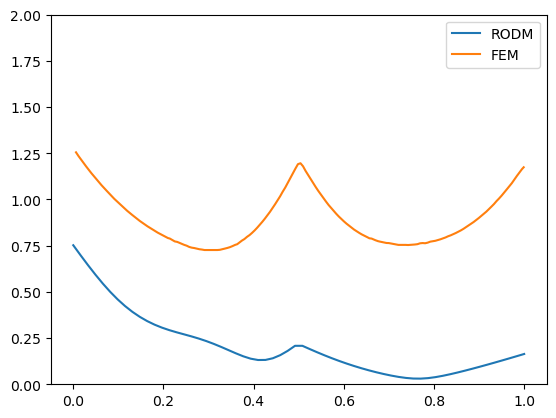

In [35]:
import matplotlib.pyplot as plt
# mid = displacement_old[(367+6)*6-6:(427+7)*6-6,:]
i = 6
x = np.linspace(0, 1, 62)
www = mid[62*i + 0:62*i + 62]
plt.plot(x,abs(www))
import pandas as pd
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Default Dataset.csv')
plt.plot(df.iloc[:, 0],df.iloc[:, 1])
plt.ylim(0,2)
plt.legend(['RODM','FEM'])

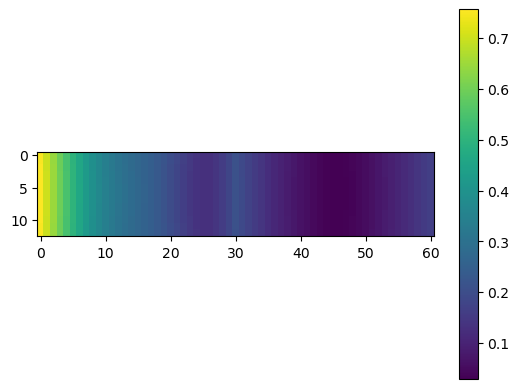

In [36]:
heave = abs(mid)
model1 = heave[0:403].reshape(13,31)
model2 = heave[403:806].reshape(13,31)
combined_model = np.hstack((model1, model2))
modified_model = np.delete(combined_model, 30, axis=1)
plt.imshow(modified_model)
plt.colorbar()

In [37]:
new_displacement = modified_model.reshape(1,793)

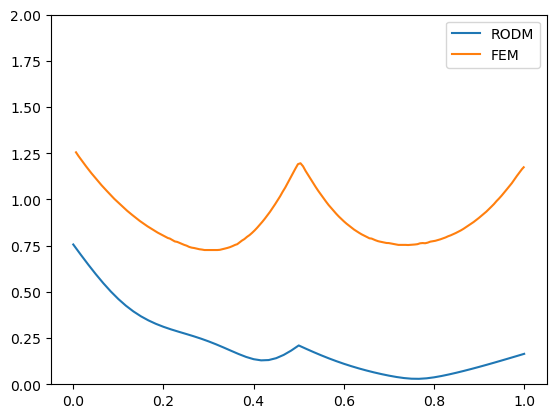

In [38]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 61)
www = new_displacement[0,366:427]
plt.plot(x,www)
import pandas as pd
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Default Dataset.csv')
plt.plot(df.iloc[:, 0],df.iloc[:, 1])
plt.ylim(0,2)
plt.legend(['RODM','FEM'])

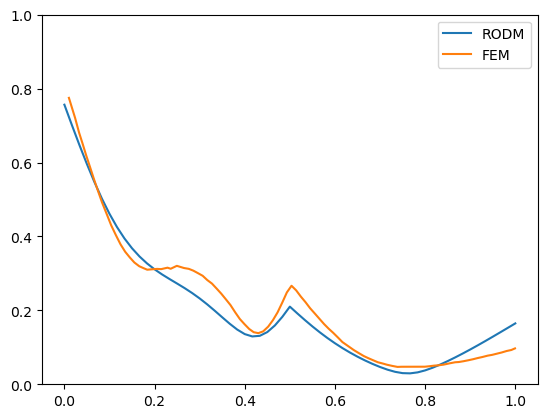

In [39]:
x = np.linspace(0, 1, 61)
www = new_displacement[0,366:427]
plt.plot(x,www)
import pandas as pd
df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Fu2007-120.csv')
plt.plot(df.iloc[:, 0],df.iloc[:, 1])
plt.ylim(0,1)
plt.legend(['RODM','FEM'])